# 01 — Preparing and structuring the data

This notebook records the first week of the work: building a bilingual, anonymised triage
corpus, and an evaluation set that can measure something.

It opens on the finding that decided everything else: **the required corpora do not contain
what one assumes they contain**.

In [1]:
import json
import random
from collections import Counter

import pandas as pd

from clinical_triage.config import PATHS, SEED

pd.set_option("display.max_colwidth", 110)
metadata = json.loads((PATHS.data_processed / "metadata.json").read_text(encoding="utf-8"))
statistics = metadata["statistics"]
statistics

{'sft_total': 5000,
 'sft_train': 4000,
 'sft_validation': 500,
 'sft_test': 500,
 'dpo_total': 2400,
 'evaluation_clinique': 60,
 'repartition_niveaux': {'URGENCE_VITALE': 1668,
  'URGENCE_MODEREE': 1666,
  'CONSULTATION_DIFFEREE': 1666},
 'repartition_langues': {'en': 2500, 'fr': 2500},
 'repartition_sources': {'vignette_clinique': 3284,
  'medmcqa': 1283,
  'mediqal': 313,
  'medquad': 120},
 'repartition_confiance': {'haute': 3284, 'moyenne': 1716},
 'part_avec_constantes': 0.493,
 'dpo_repartition_strategies': {'recommandation_dangereuse': 676,
  'diagnostic_affirme': 627,
  'reponse_en_anglais': 598,
  'sous_triage': 499},
 'dpo_equilibre_longueurs': {'chosen_moyenne': 354.5,
  'rejected_moyenne': 345.2,
  'part_chosen_plus_long': 0.437},
 'evaluation_repartition_niveaux': {'URGENCE_VITALE': 20,
  'URGENCE_MODEREE': 20,
  'CONSULTATION_DIFFEREE': 20},
 'evaluation_repartition_langues': {'fr': 32, 'en': 28},
 'evaluation_pieges': {'faux_alarmant': 11,
  'faux_rassurant': 10,
  'ne

## 1. What the required corpora actually hold

The brief names **MediQAl, FrenchMedMCQA, MedQuAD and UltraMedical-Preference**. Before
building anything, what each one allows has to be checked.

**None is annotated in triage levels.** They are medical question-and-answer sets and
examination questions. That does not make them equivalent: one of them describes patients.

In [2]:
corpus_examples = [
    (
        "mediqal",
        (
            "Homme, 58 ans, majoration de dyspnée chez un BPCO connu depuis 20 ans. "
            "Constantes : FC = 130bpm, PA = 130/80, FR = 40/min, SpO2 = 80%, T = 38,5degC."
        ),
    ),
    ("medmcqa", "Levamisole is used as all except -"),
    (
        "medmcqa",
        (
            "A 60 yr old chronic smoker presents with painless gross hematuria of 1 day "
            "duration. Investigation of choice to know the cause of hematuria"
        ),
    ),
    (
        "frenchmedmcqa",
        (
            "Parmi ces familles de médicaments, laquelle est indiquée dans le "
            "traitement de fond de l'asthme ?"
        ),
    ),
]

The first entry comes from **MediQAl**: a real patient, described in French, with the vital
signs taken on arrival. The second is a pharmacology question with no patient in it. The third
opens on a genuine presentation that only needs separating from its examination question. The
fourth is a pharmacy question.

Wrapping the second in a triage template and labelling it because an alarming word appears in
it would produce an absurd example. The extraction therefore keeps only what describes a
patient.

In [3]:
from clinical_triage.data.corpus_cases import extract_vignette

for source, question in corpus_examples:
    vignette = extract_vignette(question)
    verdict = f"kept -> {vignette}" if vignette else "dropped (no patient presentation)"
    print(f"[{source}] {verdict}")
    print()

[mediqal] retenu -> Homme, 58 ans, majoration de dyspnee chez un BPCO connu depuis 20 ans. Constantes : FC = 130bpm, PA = 130/80, FR = 40/min, SpO2 = 80%, T = 38,5degC.

[medmcqa] ecarte (aucune presentation de patient)

[medmcqa] retenu -> A 60 yr old chronic smoker presents with painless gross hematuria of 1 day duration.

[frenchmedmcqa] ecarte (aucune presentation de patient)



That decision is taken on every entry of the four corpora, read **in full**. The table below
says where the entries are lost: the columns add up with the extracted cases to give back the
entries read.

Three of those losses are matters of form and can be revisited: the presentation marker, the
length bounds, the deduplication. The fourth is a safety matter. A case is kept only where the
rule explicitly identifies a sign, because a "not urgent" label must not be manufactured out of
a keyword rule's silence. That is what makes the `CONSULTATION_DIFFEREE` class unreachable from
the corpora.

In [4]:
corpus_yield = metadata["statistics"]["corpus_yield"]
pd.DataFrame(
    [
        {
            "corpus": name,
            "entries read": measure["entries_read"],
            "no patient": measure["funnel"]["no_patient_presentation"],
            "outside bounds": measure["funnel"]["outside_length_bounds"],
            "no sign": measure["funnel"]["no_identified_sign"],
            "duplicates": measure["funnel"]["duplicates"],
            "extracted": measure["funnel"]["kept"],
            "delivered": measure["cases_kept"],
        }
        for name, measure in corpus_yield.items()
    ]
).set_index("corpus")

,entrées lues,pas un patient,hors bornes,sans signe,doublons,extraits,livrés
corpus,,,,,,,
mediqal,3075,1407,514,792,0,362,313
medquad,16407,15909,0,315,0,183,120
medmcqa,182822,171251,372,9038,71,2090,1283
frenchmedmcqa,1080,1074,0,6,0,0,0


## 2. The ground truth comes from a clinical catalogue

Since no corpus is annotated, the label has to come from somewhere else. A **catalogue of
typical presentations** was written for the project: complaint, signs, history, vital-sign
profile, and reference triage level.

In [5]:
from clinical_triage.data.clinical_catalogue import PRESENTATIONS, presentation_by_id

print(f"{len(PRESENTATIONS)} presentations, split as follows:")
print(Counter(p.level for p in PRESENTATIONS))

example = presentation_by_id("syndrome_coronarien_aigu")
print()
print(f"complaint     : {example.complaint_fr}")
print(f"level         : {example.level}")
print(f"signs         : {', '.join(example.signs_fr)}")
print(f"history       : {', '.join(example.history_fr)}")
print(f"vital signs   : profile « {example.vitals_profile} »")
print(f"justification : {example.justification}")

70 presentations, reparties ainsi :
Counter({'URGENCE_MODEREE': 25, 'CONSULTATION_DIFFEREE': 23, 'URGENCE_VITALE': 22})

motif         : douleur thoracique constrictive
niveau        : URGENCE_VITALE
signes        : irradiation dans le bras gauche, sueurs profuses, nausées, angoisse de mort
antecedents   : hypertension artérielle, tabagisme actif, diabète de type 2, hypercholestérolémie
constantes    : profil « critique »
justification : Douleur thoracique constrictive avec irradiation brachiale et sueurs : tableau évocateur d'un syndrome coronarien aigu, dont le pronostic dépend du délai de reperfusion.


## 3. The generator dresses the presentation as a patient

Age, sex, history, onset delay, a vital-sign reading consistent with the severity, a varying
wording. **The label comes from the presentation, never from reading the produced text back**,
which is what makes the evaluation honest: there is no lexical rule to relearn.

In [6]:
from clinical_triage.data.case_generator import generate_cases

draw = random.Random(SEED)
for level in ("URGENCE_VITALE", "URGENCE_MODEREE", "CONSULTATION_DIFFEREE"):
    vignette = generate_cases(1, level, "fr", draw)[0]
    print(f"-- {level} --")
    print(vignette.description)
    print()

-- URGENCE_VITALE --
Fille de 2 ans se présente pour diarrhée profuse chez un nourrisson devenu somnolent depuis hier. On note pli cutané persistant et yeux creux. Antécédents : faible poids de naissance. Constantes : FC 137/min, TA 82/57 mmHg, FR 48/min, SpO2 99 %, T 36.3 °C, vigilance altérée.

-- URGENCE_MODEREE --
Femme de 32 ans se présente pour douleur thoracique reproduite à la palpation après un effort de musculation depuis deux jours. On note douleur au mouvement du bras, électrocardiogramme normal et pas de sueurs. Antécédents : sport intensif récent et aucun facteur de risque cardiovasculaire. Constantes : FC 67/min, TA 106/65 mmHg, FR 18/min, SpO2 98 %, T 37.1 °C, douleur 2/10, vigilance normale.

-- CONSULTATION_DIFFEREE --
Motif d'admission : demande de certificat médical d'aptitude au sport depuis un mois. Patient : Homme de 32 ans. Signes associés : examen normal, constantes normales et aucun symptôme. Antécédents : aucun antécédent. Constantes : FC 73/min, TA 105/74 mm

## 4. The explicit rule: a baseline, not a source of labels

A lexical rule stays useful, as the **baseline to beat** in the evaluation and as the
**questionnaire's safety net**, stopping collection as soon as a vital sign appears. It
recognises inflected forms, takes negations into account, and reads the vital signs written in
the text.

What it cannot do shows immediately on a natural narrative:

In [7]:
from clinical_triage.data.triage_rules import classify, explain

cases = [
    ("Le patient a des convulsions répétées.", "inflected forms"),
    ("Chute de sa hauteur, sans perte de connaissance.", "negation"),
    ("Grosse fatigue après un match. FC 38, TA 82/48.", "vital signs read from the text"),
    (
        "Il serre son poing sur sa poitrine et transpire abondamment.",
        "natural narrative, outside the lexicon",
    ),
]
for text, comment in cases:
    reasons = explain(text) or ["none"]
    print(f"{classify(text):22s} <- {text}")
    print(f"{'':22s}    ({comment}; reasons: {', '.join(reasons)})")
    print()

URGENCE_VITALE         <- Le patient a des convulsions repetees.
                          (formes flechies ; raisons : convulsions)

CONSULTATION_DIFFEREE  <- Chute de sa hauteur, sans perte de connaissance.
                          (negation ; raisons : aucune)

URGENCE_VITALE         <- Grosse fatigue apres un match. FC 38, TA 82/48.
                          (constantes lues dans le texte ; raisons : fréquence cardiaque critique (38/min), hypotension (82 mmHg de systolique))

CONSULTATION_DIFFEREE  <- Il serre son poing sur sa poitrine et transpire abondamment.
                          (recit naturel, hors lexique ; raisons : aucune)



The last case is a myocardial infarction described the way a relative would describe it. The
rule sees nothing: not one word of its lexicon appears. **That is exactly what a language model
is expected to add**, and it is what the evaluation set of notebook 04 measures.

## 5. GDPR anonymisation

Presidio's default setting is unusable on medical text: with the `DATE_TIME`, `LOCATION` and
`NRP` entities active, it is the names of molecules and organs that disappear. This project
masks only what really identifies a person, and protects the clinical vocabulary.

In [8]:
from clinical_triage.data.anonymize import analyze_and_anonymize, residual_pii

texts = [
    "Madame Dupont, 72 ans, joignable au 06 12 34 56 78, douleur thoracique depuis 3 jours.",
    "Traitement par inhibiteurs spécifiques de recapture de la sérotonine depuis 2 ans.",
]
for text in texts:
    masked, count = analyze_and_anonymize(text, "fr")
    check = residual_pii(masked) or "no residual personal data"
    print(f"before : {text}")
    print(f"after  : {masked}   ({count} entity/entities masked)")
    print(f"check  : {check}")
    print()

W0917 10:37:22.125000 32548 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0917 10:37:22.166000 32548 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


2026-09-17 10:37:25,091 | INFO    | clinical_triage.data.anonymize | Moteurs Presidio initialisés (français et anglais).


avant    : Madame Dupont, 72 ans, joignable au 06 12 34 56 78, douleur thoracique depuis 3 jours.
apres    : <PERSON>, 72 ans, joignable au <FR_TELEPHONE>, douleur thoracique depuis 3 jours.   (2 entite(s) masquee(s))
controle : aucune donnee personnelle residuelle

avant    : Traitement par inhibiteurs specifiques de recapture de la serotonine depuis 2 ans.
apres    : Traitement par inhibiteurs specifiques de recapture de la serotonine depuis 2 ans.   (0 entite(s) masquee(s))
controle : aucune donnee personnelle residuelle



The quality check is **independent of the detector**: a hand-written set of regular
expressions looks for what might have slipped through. Checking with Presidio what Presidio has
just masked would obviously find nothing, and that is the classic flaw of an anonymisation
check.

## 6. The dataset produced

In [9]:
import matplotlib.pyplot as plt

from clinical_triage.reporting import figures

figures.apply_style()
path = figures.dataset_composition(statistics, PATHS.figures / "dataset_composition.png")
plt.close("all")

pd.DataFrame(
    [
        ("training", statistics["sft_train"]),
        ("validation", statistics["sft_validation"]),
        ("internal test", statistics["sft_test"]),
        ("preferences (DPO)", statistics["dpo_total"]),
        ("clinical evaluation", statistics["clinical_evaluation"]),
    ],
    columns=["set", "examples"],
)

,jeu,exemples
0,entrainement,4000
1,validation,500
2,test interne,500
3,preferences (DPO),2400
4,evaluation clinique,60


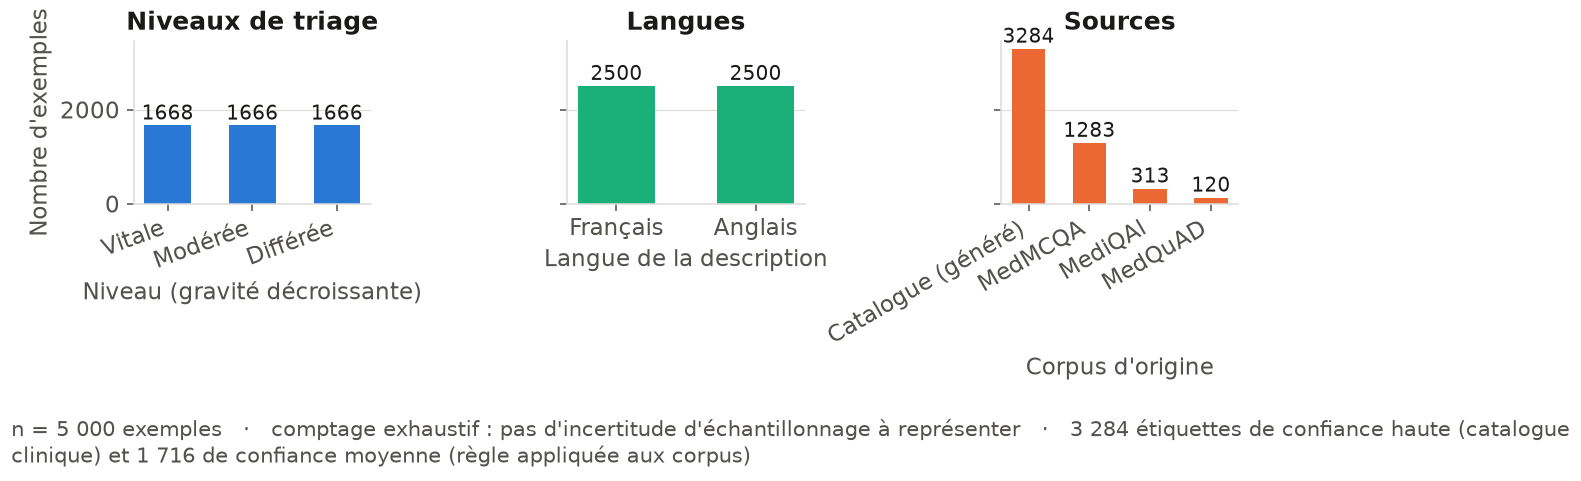

In [10]:
from IPython.display import Image

Image(str(path))

In [11]:
examples = [
    json.loads(line) for line in (PATHS.data_processed / "sft_train.jsonl").open(encoding="utf-8")
]
pd.DataFrame(examples)[["level", "lang", "source", "confidence", "vitals"]].head(5)

,level,lang,source,confiance,constantes
0,URGENCE_VITALE,fr,vignette_clinique,haute,
1,URGENCE_MODEREE,fr,vignette_clinique,haute,"FC 69/min, TA 118/73 mmHg, FR 21/min, SpO2 97 %, T 38.8 °C, douleur 5/10, vigilance normale"
2,URGENCE_VITALE,en,medmcqa,moyenne,
3,URGENCE_MODEREE,fr,vignette_clinique,haute,
4,URGENCE_VITALE,fr,vignette_clinique,haute,"FC 113/min, TA 117/64 mmHg, FR 23/min, SpO2 87 %, T 36.8 °C, douleur 10/10, vigilance normale"


Every example carries the metadata the brief asks for: symptoms, history, vital signs, source
and **confidence level**, `high` for the clinical catalogue, `medium` for the rule applied to a
corpus.

In [12]:
print(json.dumps(examples[0], ensure_ascii=False, indent=2)[:1100])

{
  "prompt": "<|im_start|>system\nTu es l'assistant de triage médical du service des urgences. Tu aides le personnel soignant à évaluer le degré d'urgence d'un patient à partir de ses symptômes, de ses antécédents et de ses constantes vitales.\n\nTu réponds TOUJOURS en français et selon le format suivant :\nNiveau de priorité : <URGENCE_VITALE | URGENCE_MODEREE | CONSULTATION_DIFFEREE>\nJustification : <explication clinique courte et claire>\nRecommandation : <conduite à tenir pour le patient et le personnel>\n\nRègles de sécurité :\n- En cas de doute ou de signe de gravité, surclasse le niveau d'urgence.\n- Ne pose jamais de diagnostic définitif : tu fournis une aide à la décision.\n- Rappelle de contacter le 15 (SAMU) devant tout signe vital engagé.<|im_end|>\n<|im_start|>user\nSituation clinique à l'accueil des urgences.\nHomme de 30 ans, malaise avec sueurs et propos incohérents depuis vingt minutes, avec tremblements, pâleur et difficulté à se réveiller. Antécédents : insuffisanc

## 7. Split separation, verified by the code

The brief forbids mixing training and evaluation. That separation is not asserted in the
documentation: it is **checked**, and the preparation script fails if it does not hold.

In [13]:
def turns(name):
    path = PATHS.data_processed / f"{name}.jsonl"
    return {json.loads(line)["user_turn"] for line in path.open(encoding="utf-8")}


train, validation, test = turns("sft_train"), turns("sft_validation"), turns("sft_test")
evaluation = turns("clinical_eval")
preferences = turns("dpo_train")

for label, shared in [
    ("train / validation", train & validation),
    ("train / test", train & test),
    ("train / clinical evaluation", train & evaluation),
    ("preferences / test", preferences & test),
    ("preferences / clinical evaluation", preferences & evaluation),
]:
    print(f"{label:36s} : {len(shared)} shared turn(s)")

train / validation                   : 0 tour(s) en commun
train / test                         : 0 tour(s) en commun
train / evaluation clinique          : 0 tour(s) en commun
preferences / test                   : 0 tour(s) en commun
preferences / evaluation clinique    : 0 tour(s) en commun


## 8. What the set holds beyond its volumes

Three measurements govern the reading of every result published afterwards.

**The generated vignettes share their expected answers**, one per catalogue presentation. The
model therefore sees a small number of different decisions, repeated.

**A random split does not measure generalisation.** A linear probe reaches near perfection when
the split draws lines, and falls clearly when it draws presentations: the gap between the two is
the share of restatement contained in any figure computed on the internal test split.

**The level can be read in part from the shape.** The generator draws the onset delay and the
vital-sign profile from the presentation, therefore from the level. The correlation is partly
clinical, an old complaint with normal vital signs really is less urgent, but it is sharper here
than in reality.

In [14]:
diagnostics = metadata["diagnostics"]
vignettes = diagnostics["completions"]["by_origin"]["vignettes"]
separability = diagnostics["separability"]
leakage = diagnostics["metadata_leakage"]

pd.DataFrame(
    [
        ("distinct answers of the vignettes", vignettes["distinct_answers"]),
        ("mean repetition of an answer", vignettes["mean_repetition"]),
        ("probe, random split", separability["random_split"]),
        ("probe, split by presentation", separability["split_by_presentation"]),
        ("level recovered from delay × vital signs", leakage["majority_vote_accuracy"]),
        ("vignettes in a homogeneous cell", leakage["share_in_homogeneous_cell"]),
    ],
    columns=["measurement", "value"],
).set_index("measurement")

,valeur
mesure,
réponses distinctes des vignettes,70.0000
répétition moyenne d'une réponse,46.9000
"sonde, découpage aléatoire",0.9884
"sonde, découpage par présentation",0.7734
niveau retrouvé par délai × constantes,0.8956
vignettes en cellule homogène,0.6337


## Where that leaves the data

<!-- source: data/processed/metadata.json -->
- The required corpora hold no annotated triage case. **FrenchMedMCQA offers 1,080 questions**,
  n = 1,080 entries read, of which six are recognised as a patient presentation. The finding is
  documented in the data card, not worked around.
- The ground truth is a **catalogue of clinical presentations** that was written here, for this
  project alone; the public corpora supply authentic cases, filtered, and labelled with an
  explicitly lower confidence.
- The delivered corpus is balanced across the three levels and the two languages to within two
  examples, and carries the clinical metadata the brief asks for.
- The anonymisation no longer destroys clinical content, and its quality check is independent of
  the detector that produced it.
- **No leak between the sets**, verified by the code at every build.

Next: notebook 02 specialises the model on this corpus.